# Determine And Validate The Clinical Preprocessing Rules

## Purpose

**This notebook finalizes preprocessing for clinical variables after EDA filtering.**

### Objectives:
- Review remaining missingness in retained clinical features
- Define deterministic handling rules (drop vs. impute)
- Document preprocessing decisions
- Prototype train-fit imputation for pipeline (fit on train, apply to val/test)

### Workflow

1. Load filtered clinical dataset  
   - Dataset already passed validity filtering during EDA.

2. Inspect remaining missingness (full cohort)  
   - Confirm missingness rates for all retained columns.  
   - Verify column types (numeric vs categorical).

3. Remove constant columns  
   - Drop columns containing only a single category across the cohort.

4. Check and handle redundant columns  
   - Identify redundant numerical and categorical encodings.  
   - Retain a single canonical representation for each concept.

5. Encode preprocessing rules  
   - Store deterministic decisions in variables/lists:
       • manual drop columns  
       • numeric imputation columns  
       • categorical imputation columns  
       • missingness indicator columns

6. Load split IDs and partition the dataset  
   - Create `X_train`, `X_val`, `X_test` using the saved split.

7. Fit imputation parameters on the training set only
   - Compute medians / modes using `X_train`.

8. Apply imputations to all splits  
   - Transform train, validation, and test using parameters learned from the training set.

9. Validate outputs  
   - Confirm no remaining missing values 
   - Verify row counts match split sizes  
   - Verify no ID drift or leakage

10. Save parameters
-   Output all preprocessing parameters to use in the preprocessing pipelinem

11. Test preprocessing module

In [22]:
import json
from pathlib import Path
import subprocess

import numpy as np
import pandas as pd
import scipy.stats as ss

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

## 1. Load filtered clinical dataset

In [2]:
# Load filtered clinical feature list and raw clinical dataset

feature_path = Path("../data/interim/clinical_features_filtered.csv")
RAW_DIR = Path("../data/raw")
clin_path = RAW_DIR / "TCGA-BRCA.clinical.tsv.gz"

feature_df = pd.read_csv(feature_path)
if "feature" not in feature_df.columns:
    raise KeyError("clinical_features_filtered.csv must contain a 'feature' column")

clinical_features = feature_df["feature"].astype(str).tolist()

clin_df = pd.read_csv(clin_path, sep="\t")
if "sample" not in clin_df.columns:
    raise KeyError("Raw clinical dataset must contain a 'sample' column")

clin_df = clin_df.set_index("sample")

missing_features = [col for col in clinical_features if col not in clin_df.columns]
if missing_features:
    raise KeyError(f"Filtered features missing from raw clinical data: {missing_features}")

clin_df = clin_df.loc[:, clinical_features].copy()

print(f"Rows: {clin_df.shape[0]:,} | Retained features: {clin_df.shape[1]:,}")
display(clin_df.head())


Rows: 1,255 | Retained features: 54


,disease_type,primary_site,alcohol_history.exposures,race.demographic,gender.demographic,ethnicity.demographic,vital_status.demographic,age_at_index.demographic,days_to_birth.demographic,year_of_birth.demographic,...,tumor_descriptor.samples,sample_type.samples,composition.samples,days_to_collection.samples,initial_weight.samples,preservation_method.samples,oct_embedded.samples,specimen_type.samples,is_ffpe.samples,tissue_type.samples
sample,,,,,,,,,,,,,,,,,,,,,
TCGA-BH-A0W3-01A,Ductal and Lobular Neoplasms,Breast,Not Reported,white,female,not hispanic or latino,Alive,58.0,-21369.0,1952.0,...,Primary,Primary Tumor,Not Reported,85.0,120.0,OCT,True,Solid Tissue,False,Tumor
TCGA-AR-A24V-01A,Ductal and Lobular Neoplasms,Breast,Not Reported,white,female,not hispanic or latino,Alive,52.0,-19027.0,1954.0,...,Primary,Primary Tumor,Not Reported,1720.0,400.0,OCT,True,Solid Tissue,False,Tumor
TCGA-E9-A1NE-01A,Ductal and Lobular Neoplasms,Breast,Not Reported,white,female,not hispanic or latino,Alive,28.0,-10564.0,1983.0,...,Primary,Primary Tumor,Not Reported,31.0,280.0,OCT,True,Solid Tissue,False,Tumor
TCGA-E9-A1NE-11A,Ductal and Lobular Neoplasms,Breast,Not Reported,white,female,not hispanic or latino,Alive,28.0,-10564.0,1983.0,...,Not Applicable,Solid Tissue Normal,Not Reported,31.0,830.0,OCT,True,Solid Tissue,False,Normal
TCGA-AC-A8OQ-01A,Ductal and Lobular Neoplasms,Breast,Not Reported,black or african american,female,not hispanic or latino,Alive,72.0,-26535.0,1939.0,...,Primary,Primary Tumor,Not Reported,742.0,100.0,Unknown,False,Solid Tissue,False,Tumor


## 2. Inspect remaining missingness (full cohort)

In [3]:
# Standardize missing-like strings before checking missingness patterns.

# Standardize missing-like strings to pd.NA for consistent missingness handling
# Example: missing_strings_to_standardize = {"", "na", "n/a", "nan", "null", "none"}
def standardize_missing_values(df, missing_strings_to_standardize):
    df = df.copy()
    object_cols = df.select_dtypes(include=["object", "string"]).columns
    df.loc[:, object_cols] = df[object_cols].apply(
        lambda col: col.str.strip().mask(col.str.strip().str.lower().isin(missing_strings_to_standardize), pd.NA)
    )
    return df

MISSING_STRINGS_TO_STANDARDIZE = {"", "na", "n/a", "nan", "null", "none"}
clin_df = standardize_missing_values(clin_df, MISSING_STRINGS_TO_STANDARDIZE)

# Check missingness patterns and column types to inform imputation strategy.
missing_rate = clin_df.isna().mean().sort_values(ascending=False)

numeric_cols = clin_df.select_dtypes(include=['number', 'bool']).columns
categorical_cols = clin_df.columns.difference(numeric_cols, sort=False)

# Integrity check: every column is classified exactly once.
if len(set(numeric_cols).intersection(set(categorical_cols))) != 0:
    raise ValueError('Column type overlap detected between numeric and categorical')

if len(numeric_cols) + len(categorical_cols) != clin_df.shape[1]:
    raise ValueError('Some columns were not classified as numeric or categorical')

col_audit = pd.DataFrame({
    'dtype': clin_df.dtypes.astype(str),
    'missing_rate': missing_rate.reindex(clin_df.columns),
    'missing_count': clin_df.isna().sum(),
})
col_audit['role'] = np.where(col_audit.index.isin(numeric_cols), 'numeric', 'categorical')
col_audit = col_audit.sort_values('missing_rate', ascending=False)

print('Missingness summary (all retained columns):')
display(col_audit)

print('Type counts:')
print(f"- numeric: {len(numeric_cols)}")
print(f"- categorical: {len(categorical_cols)}")

print('Columns with missingness > 0:')
display(col_audit.loc[col_audit['missing_rate'] > 0, ['dtype', 'role', 'missing_count', 'missing_rate']])


Missingness summary (all retained columns):


,dtype,missing_rate,missing_count,role
ajcc_staging_system_edition.diagnoses,object,0.139442,175,categorical
days_to_birth.demographic,float64,0.013546,17,numeric
age_at_earliest_diagnosis.diagnoses.xena_derived,float64,0.013546,17,numeric
age_at_earliest_diagnosis_in_years.diagnoses.xena_derived,float64,0.013546,17,numeric
age_at_diagnosis.diagnoses,float64,0.013546,17,numeric
initial_weight.samples,float64,0.011952,15,numeric
ajcc_pathologic_stage.diagnoses,object,0.010359,13,categorical
year_of_birth.demographic,float64,0.003187,4,numeric
year_of_diagnosis.diagnoses,float64,0.002390,3,numeric
days_to_collection.samples,float64,0.001594,2,numeric


Type counts:
- numeric: 11
- categorical: 43
Columns with missingness > 0:


,dtype,role,missing_count,missing_rate
ajcc_staging_system_edition.diagnoses,object,categorical,175,0.139442
days_to_birth.demographic,float64,numeric,17,0.013546
age_at_earliest_diagnosis.diagnoses.xena_derived,float64,numeric,17,0.013546
age_at_earliest_diagnosis_in_years.diagnoses.xena_derived,float64,numeric,17,0.013546
age_at_diagnosis.diagnoses,float64,numeric,17,0.013546
initial_weight.samples,float64,numeric,15,0.011952
ajcc_pathologic_stage.diagnoses,object,categorical,13,0.010359
year_of_birth.demographic,float64,numeric,4,0.003187
year_of_diagnosis.diagnoses,float64,numeric,3,0.002390
days_to_collection.samples,float64,numeric,2,0.001594


In [4]:
# Check all rows that have at least one missing value
rows_with_missing = clin_df[clin_df.isna().any(axis=1)]

print(f"Rows with >=1 missing value: {len(rows_with_missing):,}")
display(rows_with_missing)


Rows with >=1 missing value: 214


,disease_type,primary_site,alcohol_history.exposures,race.demographic,gender.demographic,ethnicity.demographic,vital_status.demographic,age_at_index.demographic,days_to_birth.demographic,year_of_birth.demographic,...,tumor_descriptor.samples,sample_type.samples,composition.samples,days_to_collection.samples,initial_weight.samples,preservation_method.samples,oct_embedded.samples,specimen_type.samples,is_ffpe.samples,tissue_type.samples
sample,,,,,,,,,,,,,,,,,,,,,
TCGA-BH-A0H6-01A,Ductal and Lobular Neoplasms,Breast,Not Reported,white,female,not reported,Alive,82.0,-30125.0,1926.0,...,Primary,Primary Tumor,Not Reported,583.0,330.0,OCT,True,Solid Tissue,False,Tumor
TCGA-A2-A0T4-01A,Ductal and Lobular Neoplasms,Breast,Not Reported,white,female,not hispanic or latino,Alive,62.0,-22849.0,1947.0,...,Primary,Primary Tumor,Not Reported,303.0,1500.0,OCT,True,Solid Tissue,False,Tumor
TCGA-A2-A0YL-01A,Ductal and Lobular Neoplasms,Breast,Not Reported,white,female,not hispanic or latino,Alive,48.0,-17702.0,1962.0,...,Primary,Primary Tumor,Not Reported,205.0,730.0,OCT,True,Solid Tissue,False,Tumor
TCGA-C8-A1HE-01A,Ductal and Lobular Neoplasms,Breast,Not Reported,asian,female,not hispanic or latino,Alive,59.0,NaN,1951.0,...,Primary,Primary Tumor,Not Reported,109.0,280.0,OCT,True,Solid Tissue,False,Tumor
TCGA-A7-A26I-01B,Ductal and Lobular Neoplasms,Breast,Not Reported,white,female,not hispanic or latino,Alive,65.0,-23948.0,1946.0,...,Primary,Primary Tumor,Not Reported,256.0,NaN,FFPE,False,Solid Tissue,True,Tumor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-AN-A0G0-01A,Ductal and Lobular Neoplasms,Breast,Not Reported,white,female,not hispanic or latino,Alive,56.0,-20504.0,1954.0,...,Primary,Primary Tumor,Not Reported,34.0,210.0,Unknown,False,Solid Tissue,False,Tumor
TCGA-AO-A0JE-01A,Ductal and Lobular Neoplasms,Breast,Not Reported,black or african american,female,not hispanic or latino,Alive,53.0,-19516.0,1952.0,...,Primary,Primary Tumor,Not Reported,1910.0,550.0,OCT,True,Solid Tissue,False,Tumor
TCGA-AO-A0J3-01A,Ductal and Lobular Neoplasms,Breast,Not Reported,white,female,not hispanic or latino,Alive,67.0,-24519.0,1942.0,...,Primary,Primary Tumor,Not Reported,220.0,1180.0,OCT,True,Solid Tissue,False,Tumor


In [5]:
# Check rows with >=1 missing value, restricted to columns that contain missing values
missing_cols = clin_df.columns[clin_df.isna().any(axis=0)]
rows_missing_cols_only = clin_df.loc[clin_df.isna().any(axis=1), missing_cols]

print(f"Columns with missing values: {len(missing_cols)}")
print(f"Rows with >=1 missing value: {rows_missing_cols_only.shape[0]:,}")
display(rows_missing_cols_only)


Columns with missing values: 35
Rows with >=1 missing value: 214


,alcohol_history.exposures,race.demographic,gender.demographic,ethnicity.demographic,vital_status.demographic,age_at_index.demographic,days_to_birth.demographic,year_of_birth.demographic,synchronous_malignancy.diagnoses,ajcc_pathologic_stage.diagnoses,...,tumor_grade.diagnoses,progression_or_recurrence.diagnoses,age_at_earliest_diagnosis.diagnoses.xena_derived,age_at_earliest_diagnosis_in_years.diagnoses.xena_derived,treatment_type.treatments.diagnoses,treatment_or_therapy.treatments.diagnoses,state.treatments.diagnoses,composition.samples,days_to_collection.samples,initial_weight.samples
sample,,,,,,,,,,,,,,,,,,,,,
TCGA-BH-A0H6-01A,Not Reported,white,female,not reported,Alive,82.0,-30125.0,1926.0,No,Stage I,...,Not Reported,not reported,30125.0,82.534247,"['Radiation Therapy, NOS', 'Pharmaceutical The...","['yes', 'yes']","['released', 'released']",Not Reported,583.0,330.0
TCGA-A2-A0T4-01A,Not Reported,white,female,not hispanic or latino,Alive,62.0,-22849.0,1947.0,No,Stage IIA,...,Not Reported,not reported,22849.0,62.600000,"['Radiation Therapy, NOS', 'Pharmaceutical The...","['no', 'yes']","['released', 'released']",Not Reported,303.0,1500.0
TCGA-A2-A0YL-01A,Not Reported,white,female,not hispanic or latino,Alive,48.0,-17702.0,1962.0,No,Stage IIIA,...,Not Reported,not reported,17702.0,48.498630,"['Pharmaceutical Therapy, NOS', 'Radiation The...","['yes', 'yes']","['released', 'released']",Not Reported,205.0,730.0
TCGA-C8-A1HE-01A,Not Reported,asian,female,not hispanic or latino,Alive,59.0,NaN,1951.0,No,Stage IIA,...,Not Reported,not reported,NaN,NaN,"['Pharmaceutical Therapy, NOS', 'Radiation The...","['yes', 'no']","['released', 'released']",Not Reported,109.0,280.0
TCGA-A7-A26I-01B,Not Reported,white,female,not hispanic or latino,Alive,65.0,-23948.0,1946.0,Not Reported,Stage IIA,...,Not Reported,not reported,23948.0,65.610959,"['Pharmaceutical Therapy, NOS', 'Radiation The...","['yes', 'yes']","['released', 'released']",Not Reported,256.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-AN-A0G0-01A,Not Reported,white,female,not hispanic or latino,Alive,56.0,-20504.0,1954.0,No,Stage IIA,...,Not Reported,not reported,20504.0,56.175342,"['Radiation Therapy, NOS', 'Pharmaceutical The...","['yes', 'yes']","['released', 'released']",Not Reported,34.0,210.0
TCGA-AO-A0JE-01A,Not Reported,black or african american,female,not hispanic or latino,Alive,53.0,-19516.0,1952.0,No,Stage IIIA,...,Not Reported,not reported,19516.0,53.468493,"['Pharmaceutical Therapy, NOS', 'Radiation The...","['yes', 'yes']","['released', 'released']",Not Reported,1910.0,550.0
TCGA-AO-A0J3-01A,Not Reported,white,female,not hispanic or latino,Alive,67.0,-24519.0,1942.0,No,Stage IIB,...,Not Reported,not reported,24519.0,67.175342,"['Pharmaceutical Therapy, NOS', 'Radiation The...","['yes', 'yes']","['released', 'released']",Not Reported,220.0,1180.0


In [6]:
# Check staging system edition categories to inform imputation strategy for this column, which has ~20% missingness.
clin_df['ajcc_staging_system_edition.diagnoses'].value_counts(dropna=False)

ajcc_staging_system_edition.diagnoses
6th    494
7th    457
NaN    175
5th     92
4th     29
3rd      8
Name: count, dtype: int64

### Missingness summary
 - Missing age variables are single sample - can impute
 - Missing weight variable is a single sample - can impute
 - 'ajcc_staging_system_edition' is a categorical variable with 6 categories, set NaN values to 'unknown'

## 3. Remove constant columns  

In [7]:
# Flag and remove constant columns (including all-missing columns).
unique_counts = clin_df.nunique(dropna=False)
constant_cols = unique_counts[unique_counts <= 1].index.tolist()

print(f'Constant columns found: {len(constant_cols)}')
if constant_cols:
    display(pd.DataFrame({'column': constant_cols, 'n_unique': unique_counts.loc[constant_cols].values}))

n_cols_before = clin_df.shape[1]
clin_df = clin_df.drop(columns=constant_cols)
n_cols_after = clin_df.shape[1]

# Integrity check: verify expected number of columns were removed.
expected_after = n_cols_before - len(constant_cols)
if n_cols_after != expected_after:
    raise ValueError(
        f'Column-count mismatch after dropping constants: expected {expected_after}, got {n_cols_after}'
    )

print(f'Columns before: {n_cols_before}')
print(f'Columns after : {n_cols_after}')


Constant columns found: 8


,column,n_unique
0,primary_site,1
1,primary_site.project,1
2,project_id.project,1
3,disease_type.project,1
4,name.project,1
5,name.program.project,1
6,project.tissue_source_site,1
7,bcr_id.tissue_source_site,1


Columns before: 54
Columns after : 46


## 4. Check for redundant columns

High-correlation pairs (>0.95): 11


,feature_1,feature_2,corr
22,age_at_diagnosis.diagnoses,age_at_earliest_diagnosis.diagnoses.xena_derived,1.000000
11,days_to_birth.demographic,age_at_earliest_diagnosis.diagnoses.xena_derived,1.000000
9,days_to_birth.demographic,age_at_diagnosis.diagnoses,1.000000
30,age_at_earliest_diagnosis.diagnoses.xena_derived,age_at_earliest_diagnosis_in_years.diagnoses.x...,1.000000
23,age_at_diagnosis.diagnoses,age_at_earliest_diagnosis_in_years.diagnoses.x...,1.000000
12,days_to_birth.demographic,age_at_earliest_diagnosis_in_years.diagnoses.x...,1.000000
0,age_at_index.demographic,days_to_birth.demographic,0.999762
4,age_at_index.demographic,age_at_earliest_diagnosis.diagnoses.xena_derived,0.999762
2,age_at_index.demographic,age_at_diagnosis.diagnoses,0.999762
5,age_at_index.demographic,age_at_earliest_diagnosis_in_years.diagnoses.x...,0.999762


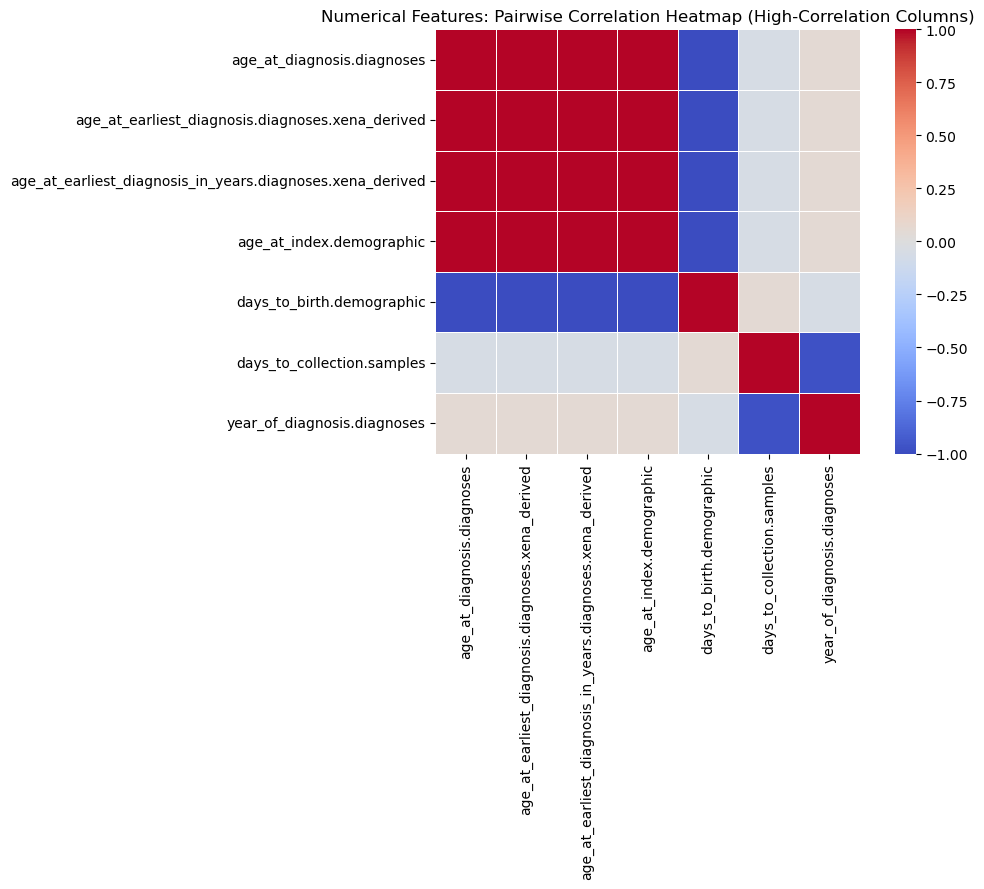

In [8]:
# Numeric redundancy

num_cols = clin_df.select_dtypes(include='number').columns
corr = clin_df[num_cols].corr().abs()

# Find highly correlated pairs (upper triangle only).
high_corr = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
high_corr.columns = ['feature_1', 'feature_2', 'corr']
high_corr = high_corr[high_corr['corr'] > 0.95].sort_values('corr', ascending=False)

print(f'High-correlation pairs (>0.95): {len(high_corr)}')
display(high_corr)

# Pairwise heatmap for columns involved in high-correlation pairs.

high_corr_cols = sorted(set(high_corr['feature_1']).union(high_corr['feature_2']))
corr_sub = clin_df[high_corr_cols].corr()

plt.figure(figsize=(1.2 * len(high_corr_cols) + 3, 1.0 * len(high_corr_cols) + 2))
sns.heatmap(
    corr_sub,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
)
plt.title('Numerical Features: Pairwise Correlation Heatmap (High-Correlation Columns)')
plt.tight_layout()
plt.show()


In [9]:
# days_to_collection.samples and year_of_diagnosis.diagnoses show moderate correlation because calendar time moves together, but they measure different things.
clin_df[["days_to_collection.samples","year_of_diagnosis.diagnoses"]].describe()

,days_to_collection.samples,year_of_diagnosis.diagnoses
count,1253.000000,1252.000000
mean,1132.055068,2007.653355
std,1491.389733,4.396019
min,16.000000,1988.000000
25%,157.000000,2006.000000
50%,486.000000,2009.000000
75%,1414.000000,2010.000000
max,7858.000000,2013.000000


In [10]:
# Check pairwise deterministic relationships between categorical variables, which can indicate redundant encodings or hierarchical relationships.

# Select categorical columns only
cat_cols = clin_df.select_dtypes("object").columns

pairs = []

# Loop over each unique pair of categorical columns
for i, c1 in enumerate(cat_cols):
    for c2 in cat_cols[i+1:]:

        # Keep only rows where both columns are present
        # This avoids treating missing values as categories
        s = clin_df[[c1, c2]].dropna()

        # Skip pairs with no overlapping non-missing data
        if s.empty:
            continue

        # Count how many unique values each column has
        n1, n2 = s[c1].nunique(), s[c2].nunique()

        # Skip pairs where either column is constant
        # Constant columns create trivial "deterministic" mappings
        # that are not useful for redundancy detection
        if n1 <= 1 or n2 <= 1:
            continue

        # Check whether c1 determines c2:
        # for each value of c1, is there only one observed value of c2?
        c1_to_c2 = s.groupby(c1)[c2].nunique().max() == 1

        # Check whether c2 determines c1:
        # for each value of c2, is there only one observed value of c1?
        c2_to_c1 = s.groupby(c2)[c1].nunique().max() == 1

        # Classify the relationship
        if c1_to_c2 and c2_to_c1:
            # Perfect one-to-one mapping: likely duplicate encodings
            pairs.append((c1, c2, "one-to-one"))
        elif c1_to_c2:
            # c1 fully determines c2
            pairs.append((c1, c2, "c1->c2"))
        elif c2_to_c1:
            # c2 fully determines c1
            pairs.append((c1, c2, "c2->c1"))

# Display all categorical pairs with deterministic relationships
pd.DataFrame(pairs, columns=["col1", "col2", "relation"])

,col1,col2,relation
0,disease_type,primary_diagnosis.diagnoses,c2->c1
1,disease_type,morphology.diagnoses,c2->c1
2,tissue_source_site_id.tissue_source_site,code.tissue_source_site,one-to-one
3,tissue_source_site_id.tissue_source_site,name.tissue_source_site,one-to-one
4,code.tissue_source_site,name.tissue_source_site,one-to-one
5,synchronous_malignancy.diagnoses,prior_malignancy.diagnoses,c2->c1
6,tissue_or_organ_of_origin.diagnoses,icd_10_code.diagnoses,c2->c1
7,tissue_or_organ_of_origin.diagnoses,site_of_resection_or_biopsy.diagnoses,one-to-one
8,primary_diagnosis.diagnoses,morphology.diagnoses,one-to-one
9,icd_10_code.diagnoses,site_of_resection_or_biopsy.diagnoses,c1->c2


In [11]:
# Manual check, if each row maps to exactly one volumn value, then there is a deterministic mapping.


pd.crosstab(clin_df['primary_diagnosis.diagnoses'], clin_df['disease_type'])

disease_type,Adenomas and Adenocarcinomas,Adnexal and Skin Appendage Neoplasms,Basal Cell Neoplasms,Complex Epithelial Neoplasms,"Cystic, Mucinous and Serous Neoplasms",Ductal and Lobular Neoplasms,"Epithelial Neoplasms, NOS",Fibroepithelial Neoplasms,Squamous Cell Neoplasms
primary_diagnosis.diagnoses,,,,,,,,,
Adenoid cystic carcinoma,1,0,0,0,0,0,0,0,0
Apocrine adenocarcinoma,0,1,0,0,0,0,0,0,0
"Basal cell carcinoma, NOS",0,0,1,0,0,0,0,0,0
"Carcinoma, NOS",0,0,0,0,0,0,1,0,0
"Cribriform carcinoma, NOS",1,0,0,0,0,0,0,0,0
Infiltrating duct and lobular carcinoma,0,0,0,0,0,38,0,0,0
"Infiltrating duct carcinoma, NOS",0,0,0,0,0,899,0,0,0
Infiltrating duct mixed with other types of carcinoma,0,0,0,0,0,21,0,0,0
Infiltrating lobular mixed with other types of carcinoma,0,0,0,0,0,8,0,0,0


Categorical columns (total): 35
Variables with >=1 Cramer's V > 0.7: 16


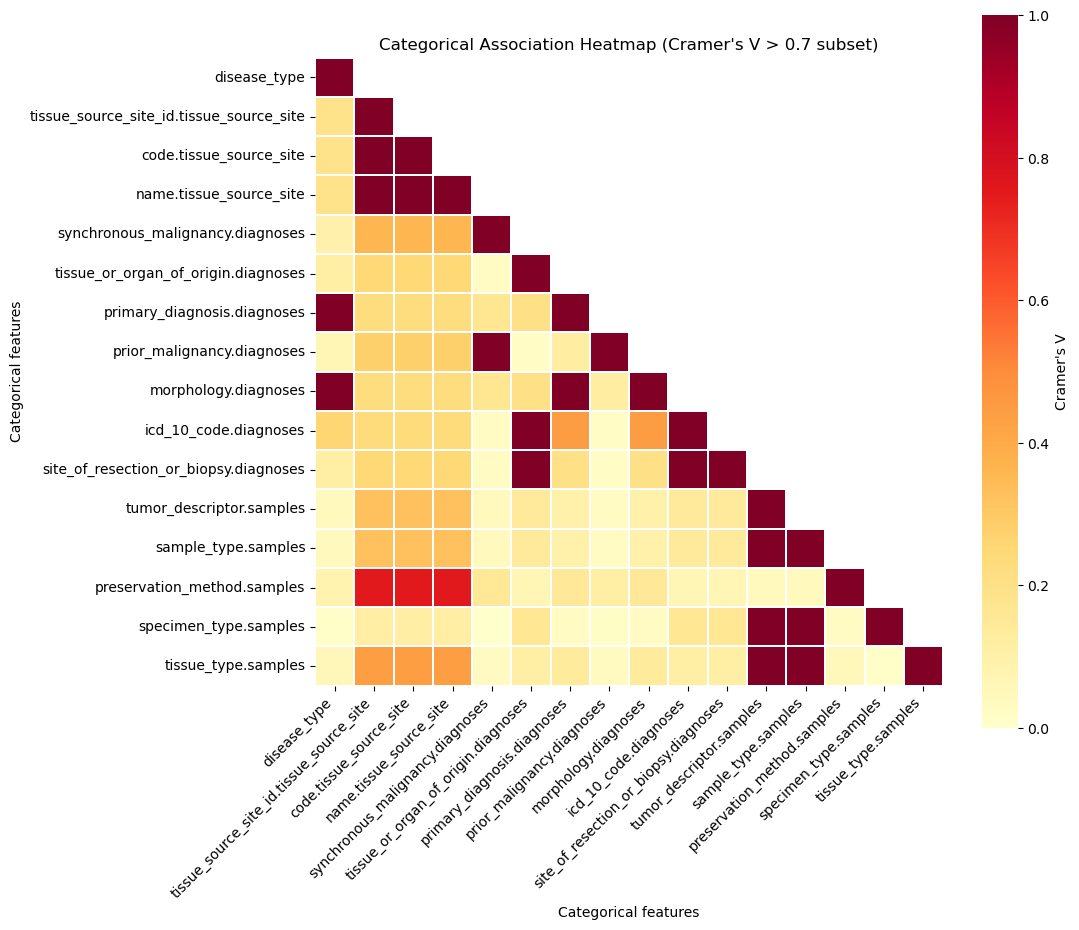

In [12]:
# Cramér’s V measures association strength between categorical variables.
# 0.0-0.3  weak
# 0.3-0.7  moderate
# 0.7-1.0  very strong


def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    if confusion.empty:
        return np.nan

    # Need at least a 2x2 contingency table for a meaningful association.
    if confusion.shape[0] < 2 or confusion.shape[1] < 2:
        return np.nan

    chi2 = ss.chi2_contingency(confusion)[0]
    n = confusion.to_numpy().sum()
    if n == 0:
        return np.nan

    phi2 = chi2 / n
    r, k = confusion.shape
    denom = min(k - 1, r - 1)
    if denom <= 0:
        return np.nan

    return np.sqrt(phi2 / denom)

# Build pairwise Cramer's V matrix for categorical columns.
cat_cols = clin_df.select_dtypes(include=['object', 'category']).columns.tolist()
if len(cat_cols) < 2:
    raise ValueError('Need at least 2 categorical columns for Cramer\'s V heatmap')

cramers_matrix = pd.DataFrame(np.nan, index=cat_cols, columns=cat_cols)

for c1 in cat_cols:
    for c2 in cat_cols:
        if c1 == c2:
            cramers_matrix.loc[c1, c2] = 1.0
            continue

        pair_df = clin_df[[c1, c2]].dropna()
        if pair_df.empty:
            continue

        cramers_matrix.loc[c1, c2] = cramers_v(pair_df[c1], pair_df[c2])

# Keep only variables that have at least one off-diagonal score > 0.7.
threshold = 0.7
off_diag = cramers_matrix.where(~np.eye(len(cramers_matrix), dtype=bool))
keep_vars = off_diag.gt(threshold).any(axis=1)
selected_cols = keep_vars[keep_vars].index.tolist()

print(f'Categorical columns (total): {len(cat_cols)}')
print(f'Variables with >=1 Cramer\'s V > {threshold}: {len(selected_cols)}')

if len(selected_cols) < 2:
    print('Fewer than 2 variables meet the threshold; heatmap not generated.')
else:
    cramers_matrix_plot = cramers_matrix.loc[selected_cols, selected_cols].astype(float)

    plt.figure(figsize=(max(8, 0.7 * len(selected_cols)), max(6, 0.6 * len(selected_cols))))
    mask = np.triu(np.ones_like(cramers_matrix_plot, dtype=bool), k=1)
    ax = sns.heatmap(
        cramers_matrix_plot,
        mask=mask,
        cmap='YlOrRd',
        vmin=0,
        vmax=1,
        square=True,
        linewidths=0.3,
        cbar_kws={'label': "Cramer's V"},
    )
    ax.set_title("Categorical Association Heatmap (Cramer's V > 0.7 subset)")
    ax.set_xlabel('Categorical features')
    ax.set_ylabel('Categorical features')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


### Redundancy decisions

These are essentially the same age variable
- Columns: 
    - age_at_diagnosis.diagnoses
    - age_at_earliest_diagnosis.diagnoses.xena_derived
    - age_at_earliest_diagnosis_in_years.diagnoses.xena_derived
    - age_at_index.demographic
    - days_to_birth.demographic
- Decision:
    - KEEP
        - age_at_earliest_diagnosis_in_years.diagnoses.xena_derived
    - DROP
        - age_at_diagnosis.diagnoses
        - age_at_earliest_diagnosis.diagnoses.xena_derived
        - age_at_index.demographic
        - days_to_birth.demographic
- Reason:
    - They encode the same age signal
    - Keep a direct years-based variable

These are different encodings of tissue source site
- Columns: 
    - tissue_source_site_id.tissue_source_site
    - code.tissue_source_site
    - name.tissue_source_site
- Decision:
    - KEEP
        - name.tissue_source_site
    - DROP
        - tissue_source_site_id.tissue_source_site
        - code.tissue_source_site
- Reason:
    - Name is the most interpretable representation

These encode overlapping diagnosis information
- Columns: 
    - disease_type
    - primary_diagnosis.diagnoses
    - morphology.diagnoses
- Decision:
    - KEEP
        - primary_diagnosis.diagnoses
    - DROP
        - disease_type
        - morphology.diagnoses
- Reason:
    - primary_diagnosis.diagnoses is the most granular standard clinical field

These have a one-to-one mapping
- Columns: 
    - synchronous_malignancy.diagnoses
    - prior_malignancy.diagnoses
- Decision:
    - KEEP
        - prior_malignancy.diagnoses
    - DROP
        - synchronous_malignancy.diagnoses
- Reason:
    - prior_malignancy.diagnoses is more clinically interpretable

These all represent the same anatomical site
- Columns: 
    - tissue_or_organ_of_origin.diagnoses
    - icd_10_code.diagnoses
    - site_of_resection_or_biopsy.diagnoses
- Decision:
    - KEEP
        - tissue_or_organ_of_origin.diagnoses
    - DROP
        - icd_10_code.diagnoses
        - site_of_resection_or_biopsy.diagnoses
- Reason:
    - ICD codes are less interpretable
    - tissue_or_organ_of_origin is clearer


## 5. Encode preprocessing rules  

In [13]:
# Imputation rules derived from missingness analysis

FEATURES_NUMERIC_MEDIAN_IMPUTE = [
    "age_at_earliest_diagnosis_in_years.diagnoses.xena_derived",
    "initial_weight.samples",
]

FEATURES_CATEGORICAL_FILL_UNKNOWN = [
    "ajcc_staging_system_edition.diagnoses"
]

In [14]:
# Manual semantic drops (redundant encodings, interpretation decisions)
MANUAL_DROP_COLS = [
    'age_at_diagnosis.diagnoses',
    'age_at_earliest_diagnosis.diagnoses.xena_derived',
    'age_at_index.demographic',
    'days_to_birth.demographic',
    'tissue_source_site_id.tissue_source_site',
    'code.tissue_source_site',
    'disease_type',
    'morphology.diagnoses',
    'synchronous_malignancy.diagnoses',
    'icd_10_code.diagnoses',
    'site_of_resection_or_biopsy.diagnoses',    
]

# Sanity checks
if len(MANUAL_DROP_COLS) != len(set(MANUAL_DROP_COLS)):
    raise ValueError('MANUAL_DROP_COLS contains duplicate entries')

missing_manual_cols = [c for c in MANUAL_DROP_COLS if c not in clin_df.columns]
if missing_manual_cols:
    raise KeyError(f'MANUAL_DROP_COLS missing from clin_df: {missing_manual_cols}')

constant_cols = list(constant_cols)
DROP_COLS = list(dict.fromkeys(MANUAL_DROP_COLS + constant_cols))

# Every final drop column must come from manual list or detected constant columns.
allowed_drop_cols = set(MANUAL_DROP_COLS).union(constant_cols)
unexpected_drop_cols = [c for c in DROP_COLS if c not in allowed_drop_cols]
if unexpected_drop_cols:
    raise ValueError(f'Unexpected columns in DROP_COLS: {unexpected_drop_cols}')

print(f'MANUAL_DROP_COLS: {len(MANUAL_DROP_COLS)}')
print(f'constant_cols: {len(constant_cols)}')
print(f'DROP_COLS (combined, deduplicated): {len(DROP_COLS)}')
display(DROP_COLS)


MANUAL_DROP_COLS: 11
constant_cols: 8
DROP_COLS (combined, deduplicated): 19


['age_at_diagnosis.diagnoses',
 'age_at_earliest_diagnosis.diagnoses.xena_derived',
 'age_at_index.demographic',
 'days_to_birth.demographic',
 'tissue_source_site_id.tissue_source_site',
 'code.tissue_source_site',
 'disease_type',
 'morphology.diagnoses',
 'synchronous_malignancy.diagnoses',
 'icd_10_code.diagnoses',
 'site_of_resection_or_biopsy.diagnoses',
 'primary_site',
 'primary_site.project',
 'project_id.project',
 'disease_type.project',
 'name.project',
 'name.program.project',
 'project.tissue_source_site',
 'bcr_id.tissue_source_site']

## 6. Load split IDs and partition the dataset  
   - Create `X_train`, `X_val`, `X_test` using the saved split.

In [15]:
# Load saved split IDs and partition clin_df, and filter the features

def load_split_ids_and_partition_clin_df(clin_df, sample_ids_path, split_dir, drop_cols):
    
    sample_ids_df = pd.read_csv(sample_ids_path)
    train_ids_df = pd.read_csv(split_dir / "train_ids.csv")
    val_ids_df = pd.read_csv(split_dir / "val_ids.csv")
    test_ids_df = pd.read_csv(split_dir / "test_ids.csv")

    sample_ids = sample_ids_df["sample"].astype(str)
    train_ids = train_ids_df["sample"].astype(str)
    val_ids = val_ids_df["sample"].astype(str)
    test_ids = test_ids_df["sample"].astype(str)

    if set(sample_ids) != set(train_ids) | set(val_ids) | set(test_ids):
        raise ValueError("Saved splits do not match sample_ids_filtered.csv")

    missing_ids = [sample_id for sample_id in sample_ids if sample_id not in clin_df.index]
    if missing_ids:
        raise ValueError(f"Some filtered samples are missing from clin_df: {missing_ids[:5]}")

    clin_df = clin_df.loc[sample_ids].copy()

    missing_drop_cols = sorted(set(drop_cols) - set(clin_df.columns))
    assert not missing_drop_cols, f"Missing drop columns in clin_df: {missing_drop_cols}"

    clin_df = clin_df.drop(columns=drop_cols)

    X_train_df = clin_df.loc[train_ids].copy()
    X_val_df = clin_df.loc[val_ids].copy()
    X_test_df = clin_df.loc[test_ids].copy()

    return clin_df, train_ids, val_ids, test_ids, X_train_df, X_val_df, X_test_df

split_dir = Path("../data/processed/splits/os_seed42_v15_t15")
sample_ids_path = Path("../data/interim/sample_ids_filtered.csv")

clin_df, train_ids, val_ids, test_ids, X_train_df, X_val_df, X_test_df = load_split_ids_and_partition_clin_df(
    clin_df=clin_df,
    sample_ids_path=sample_ids_path,
    split_dir=split_dir,
    drop_cols=MANUAL_DROP_COLS,
)

print(X_train_df.shape, X_val_df.shape, X_test_df.shape)
display(X_train_df.head(), X_train_df.tail())


(203, 35) (43, 35) (44, 35)


,alcohol_history.exposures,race.demographic,gender.demographic,ethnicity.demographic,vital_status.demographic,year_of_birth.demographic,name.tissue_source_site,ajcc_pathologic_stage.diagnoses,last_known_disease_status.diagnoses,tissue_or_organ_of_origin.diagnoses,...,tumor_descriptor.samples,sample_type.samples,composition.samples,days_to_collection.samples,initial_weight.samples,preservation_method.samples,oct_embedded.samples,specimen_type.samples,is_ffpe.samples,tissue_type.samples
sample,,,,,,,,,,,,,,,,,,,,,
TCGA-AR-A1AN-01A,Not Reported,white,female,hispanic or latino,Alive,1960.0,Mayo,Stage IIA,not reported,"Breast, NOS",...,Primary,Primary Tumor,Not Reported,1463.0,70.0,OCT,True,Solid Tissue,False,Tumor
TCGA-B6-A2IU-01A,Not Reported,white,female,hispanic or latino,Alive,1936.0,Duke,Stage IIA,not reported,"Breast, NOS",...,Primary,Primary Tumor,Not Reported,4665.0,140.0,OCT,True,Solid Tissue,False,Tumor
TCGA-C8-A12Q-01A,Not Reported,asian,female,not hispanic or latino,Dead,1932.0,ILSBio,Stage IIIA,not reported,"Breast, NOS",...,Primary,Primary Tumor,Not Reported,57.0,810.0,OCT,True,Solid Tissue,False,Tumor
TCGA-BH-A0E9-01B,Not Reported,white,female,not reported,Alive,1953.0,University of Pittsburgh,Stage IIB,not reported,"Breast, NOS",...,Primary,Primary Tumor,Not Reported,1357.0,480.0,OCT,True,Solid Tissue,False,Tumor
TCGA-A2-A0ST-01A,Not Reported,white,female,not hispanic or latino,Alive,1941.0,Walter Reed,Stage IIA,not reported,"Breast, NOS",...,Primary,Primary Tumor,Not Reported,2597.0,210.0,OCT,True,Solid Tissue,False,Tumor


,alcohol_history.exposures,race.demographic,gender.demographic,ethnicity.demographic,vital_status.demographic,year_of_birth.demographic,name.tissue_source_site,ajcc_pathologic_stage.diagnoses,last_known_disease_status.diagnoses,tissue_or_organ_of_origin.diagnoses,...,tumor_descriptor.samples,sample_type.samples,composition.samples,days_to_collection.samples,initial_weight.samples,preservation_method.samples,oct_embedded.samples,specimen_type.samples,is_ffpe.samples,tissue_type.samples
sample,,,,,,,,,,,,,,,,,,,,,
TCGA-GM-A2DM-01A,Not Reported,white,female,hispanic or latino,Alive,1947.0,MD Anderson,Stage IIA,not reported,"Breast, NOS",...,Primary,Primary Tumor,Not Reported,2464.0,120.0,Unknown,False,Solid Tissue,False,Tumor
TCGA-AR-A2LE-01A,Not Reported,white,female,not hispanic or latino,Alive,1932.0,Mayo,Stage I,not reported,"Breast, NOS",...,Primary,Primary Tumor,Not Reported,3755.0,320.0,OCT,True,Solid Tissue,False,Tumor
TCGA-E2-A1LK-01A,Not Reported,black or african american,female,not hispanic or latino,Dead,1924.0,Roswell Park,Stage IIIC,not reported,"Breast, NOS",...,Primary,Primary Tumor,Not Reported,1051.0,70.0,Unknown,False,Solid Tissue,False,Tumor
TCGA-E9-A1RB-01A,Not Reported,white,female,not hispanic or latino,Dead,1971.0,Asterand,Stage IIA,not reported,"Breast, NOS",...,Primary,Primary Tumor,Not Reported,39.0,490.0,OCT,True,Solid Tissue,False,Tumor
TCGA-B6-A0I6-01A,Not Reported,black or african american,female,not hispanic or latino,Dead,1941.0,Duke,Stage IIA,not reported,"Breast, NOS",...,Primary,Primary Tumor,Not Reported,7362.0,200.0,OCT,True,Solid Tissue,False,Tumor



## 7. Fit imputation parameters on the training set only  
   - Compute medians / modes using `X_train`.

In [16]:
# Fit numeric imputation parameters on X_train_df only

def fit_numeric_median_imputation_parameters(X_train_df, features_numeric_median_impute):
    
    missing_numeric_impute_cols = sorted(set(features_numeric_median_impute) - set(X_train_df.columns))
    assert not missing_numeric_impute_cols, (
        f"FEATURES_NUMERIC_MEDIAN_IMPUTE columns missing from X_train_df: {missing_numeric_impute_cols}"
    )

    features_numeric_medians = (
        X_train_df[features_numeric_median_impute]
        .median()
        .rename("median")
        .to_frame()
        .reset_index()
        .rename(columns={"index": "feature"})
    )

    return features_numeric_medians

FEATURES_NUMERIC_MEDIANS = fit_numeric_median_imputation_parameters(
    X_train_df=X_train_df,
    features_numeric_median_impute=FEATURES_NUMERIC_MEDIAN_IMPUTE,
)

print(f"Numeric features with median imputations: {len(FEATURES_NUMERIC_MEDIANS)}")
display(FEATURES_NUMERIC_MEDIANS)

Numeric features with median imputations: 2


,feature,median
0,age_at_earliest_diagnosis_in_years.diagnoses.x...,57.260274
1,initial_weight.samples,215.000000



## 8. Apply imputations to all splits  
   - Transform train, validation, and test using parameters learned from the training set.


In [17]:
# Apply numeric median imputations to train, validation, and test

def apply_numeric_median_imputations(
    X_train_df,
    X_val_df,
    X_test_df,
    features_numeric_median_impute,
    features_numeric_medians,
):
    numeric_median_map = features_numeric_medians.set_index("feature")["median"]

    X_train_df = X_train_df.copy()
    X_val_df = X_val_df.copy()
    X_test_df = X_test_df.copy()

    X_train_df.loc[:, features_numeric_median_impute] = X_train_df[features_numeric_median_impute].fillna(numeric_median_map)
    X_val_df.loc[:, features_numeric_median_impute] = X_val_df[features_numeric_median_impute].fillna(numeric_median_map)
    X_test_df.loc[:, features_numeric_median_impute] = X_test_df[features_numeric_median_impute].fillna(numeric_median_map)

    return X_train_df, X_val_df, X_test_df

X_train_df, X_val_df, X_test_df = apply_numeric_median_imputations(
    X_train_df=X_train_df,
    X_val_df=X_val_df,
    X_test_df=X_test_df,
    features_numeric_median_impute=FEATURES_NUMERIC_MEDIAN_IMPUTE,
    features_numeric_medians=FEATURES_NUMERIC_MEDIANS,
)

display(X_train_df[FEATURES_NUMERIC_MEDIAN_IMPUTE].isna().sum().rename("train_missing_after"))
display(X_val_df[FEATURES_NUMERIC_MEDIAN_IMPUTE].isna().sum().rename("val_missing_after"))
display(X_test_df[FEATURES_NUMERIC_MEDIAN_IMPUTE].isna().sum().rename("test_missing_after"))

age_at_earliest_diagnosis_in_years.diagnoses.xena_derived    0
initial_weight.samples                                       0
Name: train_missing_after, dtype: int64

age_at_earliest_diagnosis_in_years.diagnoses.xena_derived    0
initial_weight.samples                                       0
Name: val_missing_after, dtype: int64

age_at_earliest_diagnosis_in_years.diagnoses.xena_derived    0
initial_weight.samples                                       0
Name: test_missing_after, dtype: int64

In [18]:
# Fill selected categorical features with "unknown" in train, validation, and test

def fill_unknown_for_selected_categorical_features(
    X_train_df,
    X_val_df,
    X_test_df,
    features_categorical_fill_unknown,
):
    missing_categorical_fill_cols = sorted(set(features_categorical_fill_unknown) - set(X_train_df.columns))
    assert not missing_categorical_fill_cols, (
        f"FEATURES_CATEGORICAL_FILL_UNKNOWN columns missing from X_train_df: {missing_categorical_fill_cols}"
    )

    X_train_df = X_train_df.copy()
    X_val_df = X_val_df.copy()
    X_test_df = X_test_df.copy()

    X_train_df.loc[:, features_categorical_fill_unknown] = (
        X_train_df[features_categorical_fill_unknown].fillna("unknown")
    )
    X_val_df.loc[:, features_categorical_fill_unknown] = (
        X_val_df[features_categorical_fill_unknown].fillna("unknown")
    )
    X_test_df.loc[:, features_categorical_fill_unknown] = (
        X_test_df[features_categorical_fill_unknown].fillna("unknown")
    )

    return X_train_df, X_val_df, X_test_df

X_train_df, X_val_df, X_test_df = fill_unknown_for_selected_categorical_features(
    X_train_df=X_train_df,
    X_val_df=X_val_df,
    X_test_df=X_test_df,
    features_categorical_fill_unknown=FEATURES_CATEGORICAL_FILL_UNKNOWN,
)

display(X_train_df[FEATURES_CATEGORICAL_FILL_UNKNOWN].isna().sum().rename("train_missing_after"))
display(X_val_df[FEATURES_CATEGORICAL_FILL_UNKNOWN].isna().sum().rename("val_missing_after"))
display(X_test_df[FEATURES_CATEGORICAL_FILL_UNKNOWN].isna().sum().rename("test_missing_after"))

ajcc_staging_system_edition.diagnoses    0
Name: train_missing_after, dtype: int64

ajcc_staging_system_edition.diagnoses    0
Name: val_missing_after, dtype: int64

ajcc_staging_system_edition.diagnoses    0
Name: test_missing_after, dtype: int64


## 9. Validate outputs  
   - Confirm no remaining missing values  
   - Verify row counts match split sizes  
   - Verify no ID drift or leakage

In [19]:
# Validate imputed outputs

def validate_imputed_outputs(X_train_df, X_val_df, X_test_df, train_ids, val_ids, test_ids):
    for split_name, split_df, split_ids in [
        ("train", X_train_df, train_ids),
        ("val", X_val_df, val_ids),
        ("test", X_test_df, test_ids),
    ]:
        missing_total = int(split_df.isna().sum().sum())
        if missing_total != 0:
            raise ValueError(f"{split_name} split still has {missing_total} missing values")

        if len(split_df) != len(split_ids):
            raise ValueError(
                f"{split_name} row count mismatch: expected {len(split_ids)}, got {len(split_df)}"
            )

        if split_df.index.duplicated().any():
            raise ValueError(f"{split_name} split contains duplicate sample IDs")

        if list(split_df.index.astype(str)) != list(split_ids.astype(str)):
            raise ValueError(f"{split_name} sample IDs do not match the saved split order")

    train_id_set = set(X_train_df.index.astype(str))
    val_id_set = set(X_val_df.index.astype(str))
    test_id_set = set(X_test_df.index.astype(str))

    if not train_id_set.isdisjoint(val_id_set):
        raise ValueError("Leakage detected between train and val")
    if not train_id_set.isdisjoint(test_id_set):
        raise ValueError("Leakage detected between train and test")
    if not val_id_set.isdisjoint(test_id_set):
        raise ValueError("Leakage detected between val and test")

validate_imputed_outputs(
    X_train_df=X_train_df,
    X_val_df=X_val_df,
    X_test_df=X_test_df,
    train_ids=train_ids,
    val_ids=val_ids,
    test_ids=test_ids,
)

print("All validation checks passed.")
print(f"train: {X_train_df.shape}")
print(f"val:   {X_val_df.shape}")
print(f"test:  {X_test_df.shape}")


All validation checks passed.
train: (203, 35)
val:   (43, 35)
test:  (44, 35)


## 10. Save parameters
-   Output all preprocessing parameters to use in the preprocessing pipeline

In [20]:
# Save preprocessing parameters for scripts/preprocess_clinical.py

def save_clinical_preprocess_parameters(
    params_path,
    missing_strings_to_standardize,
    features_numeric_median_impute,
    features_categorical_fill_unknown,
    manual_drop_cols,
    drop_cols,
    features_numeric_medians,
):
    params_path.parent.mkdir(parents=True, exist_ok=True)

    clinical_preprocess_parameters = {
        "MISSING_STRINGS_TO_STANDARDIZE": sorted(missing_strings_to_standardize),
        "FEATURES_NUMERIC_MEDIAN_IMPUTE": features_numeric_median_impute,
        "FEATURES_CATEGORICAL_FILL_UNKNOWN": features_categorical_fill_unknown,
        "MANUAL_DROP_COLS": manual_drop_cols,
        "DROP_COLS": drop_cols,
        "FEATURES_NUMERIC_MEDIANS": dict(
            zip(features_numeric_medians["feature"], features_numeric_medians["median"])
        ),
    }

    params_path.write_text(json.dumps(clinical_preprocess_parameters, indent=2), encoding="utf-8")
    return clinical_preprocess_parameters

params_path = Path("../data/interim/clinical_preprocess_parameters.json")
clinical_preprocess_parameters = save_clinical_preprocess_parameters(
    params_path=params_path,
    missing_strings_to_standardize=MISSING_STRINGS_TO_STANDARDIZE,
    features_numeric_median_impute=FEATURES_NUMERIC_MEDIAN_IMPUTE,
    features_categorical_fill_unknown=FEATURES_CATEGORICAL_FILL_UNKNOWN,
    manual_drop_cols=MANUAL_DROP_COLS,
    drop_cols=DROP_COLS,
    features_numeric_medians=FEATURES_NUMERIC_MEDIANS,
)

print(f"Saved parameters to {params_path}")
display(clinical_preprocess_parameters)


Saved parameters to ../data/interim/clinical_preprocess_parameters.json


{'MISSING_STRINGS_TO_STANDARDIZE': ['', 'n/a', 'na', 'nan', 'none', 'null'],
 'FEATURES_NUMERIC_MEDIAN_IMPUTE': ['age_at_earliest_diagnosis_in_years.diagnoses.xena_derived',
  'initial_weight.samples'],
 'FEATURES_CATEGORICAL_FILL_UNKNOWN': ['ajcc_staging_system_edition.diagnoses'],
 'MANUAL_DROP_COLS': ['age_at_diagnosis.diagnoses',
  'age_at_earliest_diagnosis.diagnoses.xena_derived',
  'age_at_index.demographic',
  'days_to_birth.demographic',
  'tissue_source_site_id.tissue_source_site',
  'code.tissue_source_site',
  'disease_type',
  'morphology.diagnoses',
  'synchronous_malignancy.diagnoses',
  'icd_10_code.diagnoses',
  'site_of_resection_or_biopsy.diagnoses'],
 'DROP_COLS': ['age_at_diagnosis.diagnoses',
  'age_at_earliest_diagnosis.diagnoses.xena_derived',
  'age_at_index.demographic',
  'days_to_birth.demographic',
  'tissue_source_site_id.tissue_source_site',
  'code.tissue_source_site',
  'disease_type',
  'morphology.diagnoses',
  'synchronous_malignancy.diagnoses',
  'i

## 11. Test preprocessing module

In [23]:
# Test preprocessing module

result = subprocess.run(
    [
        "python",
        "../scripts/preprocess_clinical.py",
        "--clinical-path",
        "../data/raw/TCGA-BRCA.clinical.tsv.gz",
        "--feature-path",
        "../data/interim/clinical_features_filtered.csv",
        "--sample-ids-path",
        "../data/interim/sample_ids_filtered.csv",
        "--config-path",
        "../data/interim/clinical_preprocess_parameters.json",
        "--split-dir",
        "../data/processed/splits/os_seed42_v15_t15",
        "--outdir",
        "../data/processed/clinical",
        "--params-out",
        "../data/interim/clinical_preprocess_parameters.json",
    ],
    capture_output=True,
    text=True,
)

print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError(f"preprocess_clinical.py failed with exit code {result.returncode}")
